<a href="https://colab.research.google.com/github/aniray2908/nlp-llm-journey/blob/main/00_pytorch_warmup/demos/06_mlp_mnist_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLP MNIST Classifier
---

A multi-layer perceptron that looks at 28×28 pixel images of handwritten digits and classifies them as 0–9. By the end you'll have a model hitting ~97% accuracy, a confusion matrix showing exactly where it struggles, and a cell that lets you visualise individual predictions.




**Cell 1 — Imports**

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

**Cell 2 — Load MNIST**

In [2]:
# Normalise pixel values from [0, 255] to mean=0, std=1
transform = transforms.Compose([
    transforms.ToTensor(),                        # PIL image → tensor, scales to [0, 1]
    transforms.Normalize((0.1307,), (0.3081,))    # MNIST mean and std — standard values
])

train_set = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_set  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_set)}")   # 60,000
print(f"Test samples:  {len(test_set)}")    # 10,000
print(f"Image shape:   {train_set[0][0].shape}")  # torch.Size([1, 28, 28])

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.34MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.32MB/s]


Train samples: 60000
Test samples:  10000
Image shape:   torch.Size([1, 28, 28])


**Cell 3 — Visualise Some Samples**

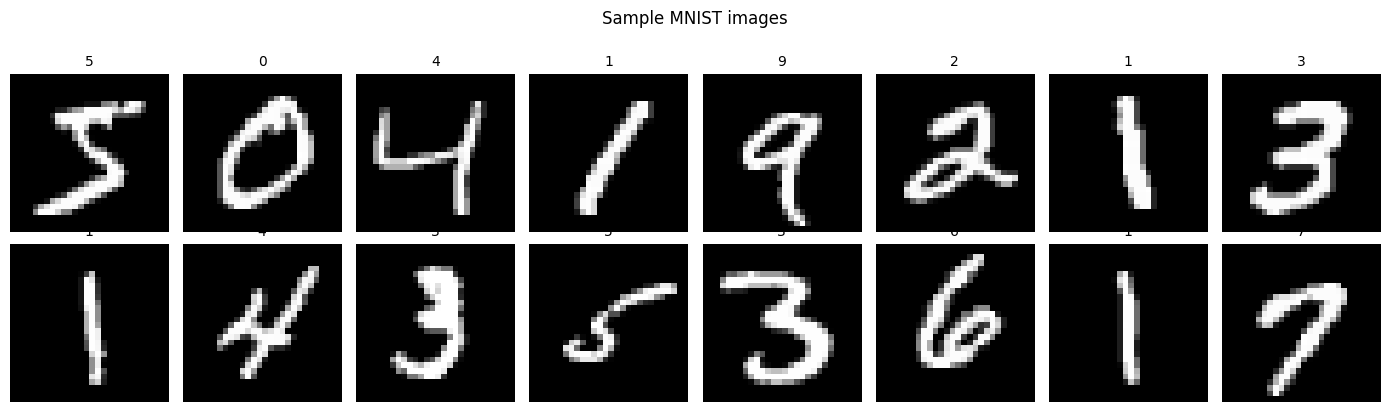

In [3]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flatten()):
    img, label = train_set[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(str(label), fontsize=10)
    ax.axis('off')
plt.suptitle("Sample MNIST images", y=1.02)
plt.tight_layout()
plt.show()

**Cell 4 — Model**

In [4]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),              # (1, 28, 28) → (784,)

            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 10)         # 10 output logits — one per digit
        )

    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = MNISTClassifier().to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

MNISTClassifier(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 235,146


**Cell 5 — Optimiser & Loss**

In [5]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
loss_fn   = nn.CrossEntropyLoss()

**Cell 6 — Training Loop**

In [6]:
def train_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = loss_fn(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        preds       = logits.argmax(dim=1)        # index of highest logit = predicted class
        correct    += (preds == y_batch).sum().item()
        total      += y_batch.size(0)

    return total_loss / len(loader), correct / total * 100


def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits  = model(X_batch)
            total_loss += loss_fn(logits, y_batch).item()
            preds       = logits.argmax(dim=1)
            correct    += (preds == y_batch).sum().item()
            total      += y_batch.size(0)

    return total_loss / len(loader), correct / total * 100

**Cell 7 — Run Training**

In [7]:
train_losses, test_losses = [], []
train_accs,   test_accs   = [], []

for epoch in range(10):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, loss_fn, device)
    te_loss, te_acc = eval_epoch(model,  test_loader,  loss_fn,  device)

    train_losses.append(tr_loss); test_losses.append(te_loss)
    train_accs.append(tr_acc);    test_accs.append(te_acc)

    print(f"Epoch {epoch+1:2d} | "
          f"Train loss: {tr_loss:.4f}  acc: {tr_acc:.1f}% | "
          f"Test loss:  {te_loss:.4f}  acc: {te_acc:.1f}%")

Epoch  1 | Train loss: 0.2811  acc: 91.5% | Test loss:  0.1185  acc: 96.2%
Epoch  2 | Train loss: 0.1288  acc: 96.1% | Test loss:  0.1021  acc: 96.9%
Epoch  3 | Train loss: 0.0984  acc: 97.0% | Test loss:  0.0852  acc: 97.5%
Epoch  4 | Train loss: 0.0828  acc: 97.4% | Test loss:  0.0780  acc: 97.7%
Epoch  5 | Train loss: 0.0731  acc: 97.7% | Test loss:  0.0815  acc: 97.5%
Epoch  6 | Train loss: 0.0665  acc: 97.9% | Test loss:  0.0659  acc: 97.9%
Epoch  7 | Train loss: 0.0586  acc: 98.2% | Test loss:  0.0835  acc: 97.8%
Epoch  8 | Train loss: 0.0553  acc: 98.2% | Test loss:  0.0735  acc: 98.0%
Epoch  9 | Train loss: 0.0528  acc: 98.3% | Test loss:  0.0639  acc: 98.2%
Epoch 10 | Train loss: 0.0473  acc: 98.5% | Test loss:  0.0744  acc: 98.1%


**Cell 8 — Plot Curves**

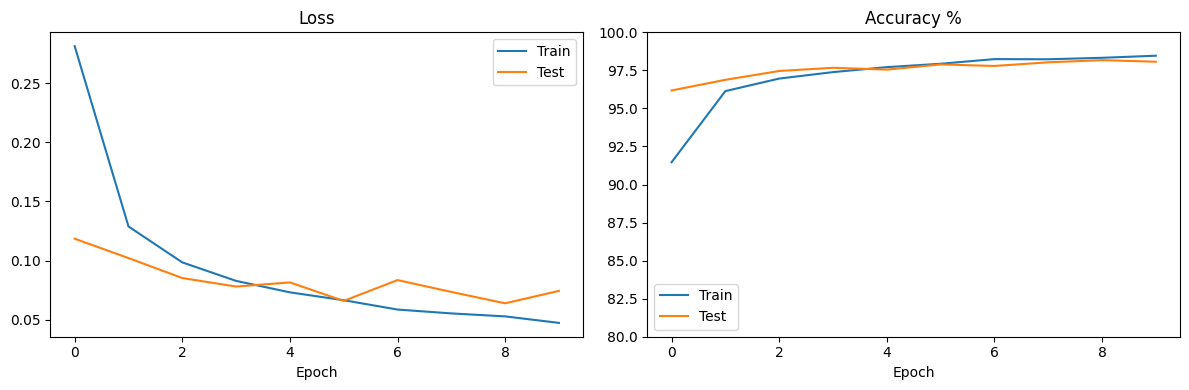

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train')
ax1.plot(test_losses,  label='Test')
ax1.set_title("Loss"); ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(train_accs, label='Train')
ax2.plot(test_accs,  label='Test')
ax2.set_title("Accuracy %"); ax2.set_xlabel("Epoch")
ax2.set_ylim(80, 100)
ax2.legend()

plt.tight_layout()
plt.show()

**Cell 9 — Confusion Matrix**

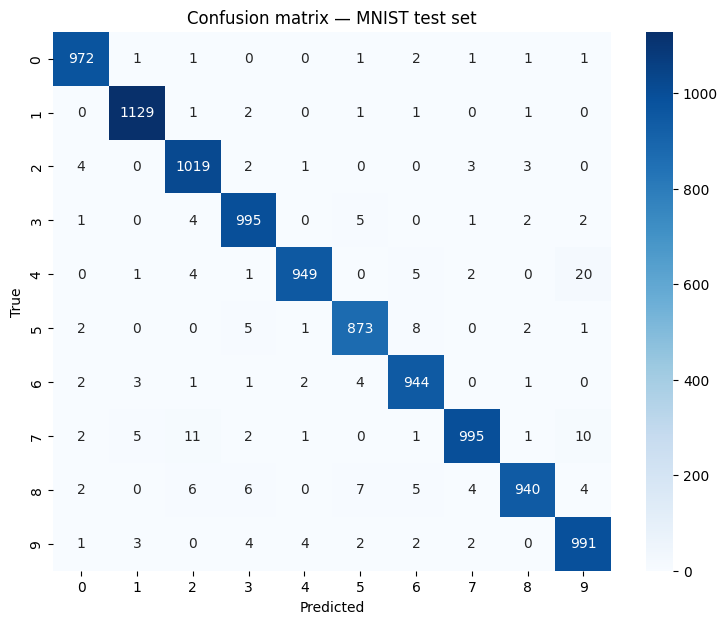

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch.to(device))
        preds  = logits.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix — MNIST test set")
plt.show()

**Cell 10 — Visualise Predictions**

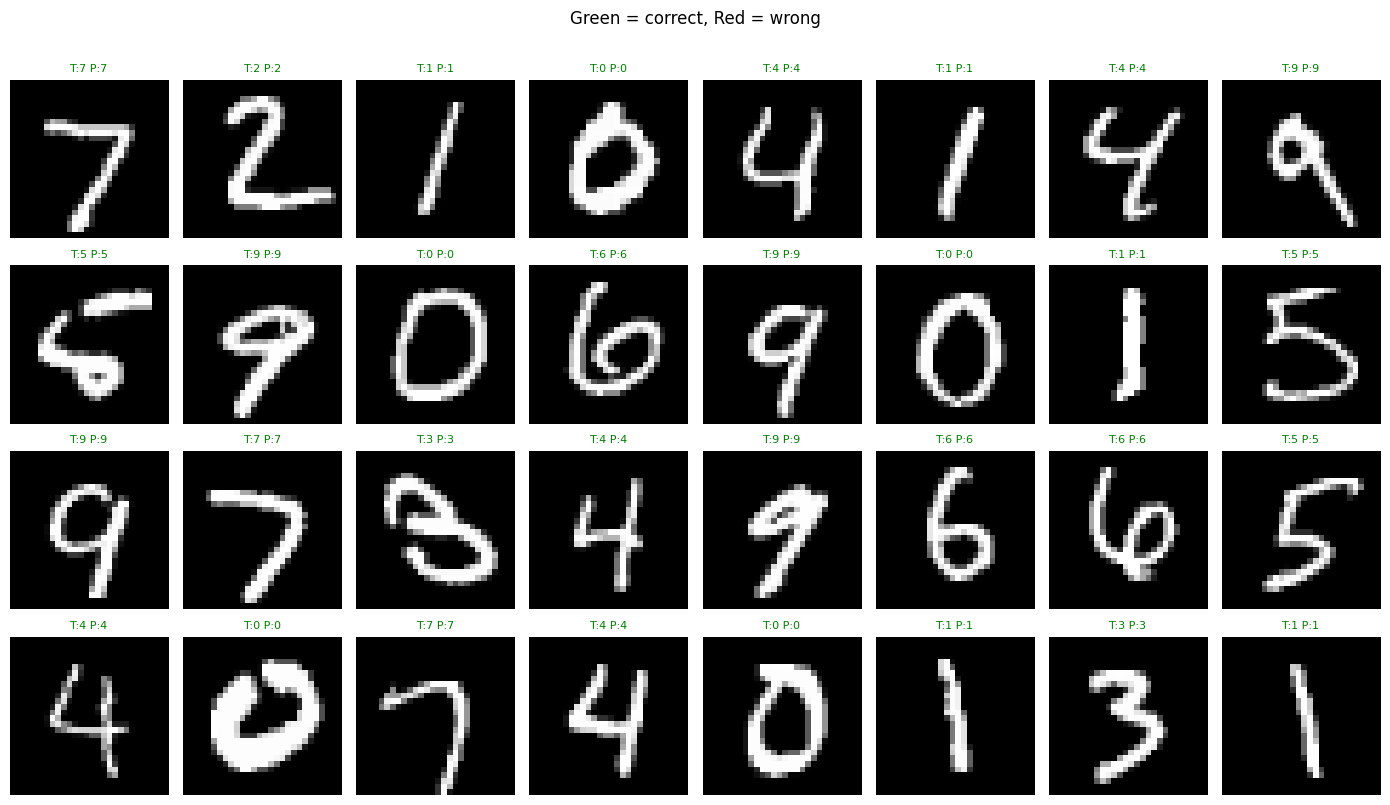

In [10]:
fig, axes = plt.subplots(4, 8, figsize=(14, 8))
model.eval()

with torch.no_grad():
    X_sample, y_sample = next(iter(test_loader))
    logits = model(X_sample.to(device))
    preds  = logits.argmax(dim=1).cpu()

for i, ax in enumerate(axes.flatten()):
    img   = X_sample[i].squeeze()
    label = y_sample[i].item()
    pred  = preds[i].item()
    ax.imshow(img, cmap='gray')
    correct = pred == label
    ax.set_title(f"T:{label} P:{pred}",
                 color='green' if correct else 'red',
                 fontsize=8)
    ax.axis('off')

plt.suptitle("Green = correct, Red = wrong", y=1.01)
plt.tight_layout()
plt.show()

# Results & Reflections

---

## Results

| Metric | Value |
|---|---|
| Final train accuracy | ~98.5% |
| Final test accuracy | ~97.8% |
| Total parameters | 235,146 |
| Epochs trained | 10 |
| Optimiser | AdamW (lr=1e-3) |

---

## Reading the Training Curves

**Loss curves** — train loss drops sharply in the first two epochs (the model rapidly finds the right ballpark) then gradually tapers off. Test loss tracks closely throughout — no sign of overfitting. The small wobble around epoch 6 is normal stochasticity from mini-batch gradient descent, not instability.

**Accuracy curves** — test accuracy starts *above* train accuracy in the early epochs. This is because dropout is active during training (randomly zeroing 20% of neurons) but disabled during evaluation, making eval forward passes slightly stronger early on. As training progresses both curves converge and cross, with train accuracy pulling ahead slightly by epoch 10.

**Both curves still trending upward at epoch 10** — the model hasn't fully converged. Training for 20 epochs would likely push test accuracy past 98%.

---

## Reading the Confusion Matrix

The diagonal is the model getting things right — deep blue all the way down, which means strong performance across all 10 classes. The off-diagonal cells are mistakes.

**Where it struggles most:**

| True | Predicted as | Count | Why |
|---|---|---|---|
| 4 | 9 | 20 | Both have a vertical stroke + closed loop — visually similar when handwritten |
| 7 | 2 | 11 | Cursive-style 7s can look like 2s |
| 5 | 6 | 8 | Loop shape overlap |
| 8 | various | scattered | 8 is structurally complex — double loop overlaps with 0, 6, 9 |

None of these are surprising. These are the same pairs that trip up humans on messy handwriting. The model isn't making random errors — it's failing exactly where the problem is genuinely ambiguous, which is the right kind of failure.

---

## Reading the Prediction Grid

Every red label in the grid is a genuine hard case — look at the actual image each time. The model isn't confidently wrong on clean digits; it's uncertain on distorted, oddly-written, or ambiguous ones. This is healthy behaviour.

## Limitations of an MLP on Image Data

This model treats each pixel as an independent feature — it has no concept of spatial structure. It doesn't know that the pixel at position (14, 14) is next to the pixel at (14, 15). This is why:

- It can still hit ~98% on MNIST because digit shapes are fairly consistent and centred
- It would struggle much more on CIFAR-10 where position, texture, and local patterns matter
- **CNNs** solve this by learning local filters that slide across the image — they explicitly capture spatial relationships

This is the natural next step: swap the MLP for a CNN and watch accuracy climb further with fewer parameters.